# Phase 3B: Feature-Based Synthetic Baseline Model

This notebook creates a separate feature-driven synthetic scenario using the real objective feature vectors of the twelve selected stimuli.

It is intentionally distinct from:

1. the original categorical synthetic dataset from Notebook 1;
2. the categorical stimulus model from Notebook 2;
3. future real participant data.

The fitted effects below are checks of a hypothetical simulation design. They are not empirical listener findings.

## 1. Imports, Runtime Configuration, and Paths

In [1]:
from __future__ import annotations

import importlib.metadata as metadata
import json
import os
import re
import sys
import time
import warnings
from pathlib import Path

CACHE_ROOT = Path(os.environ.get("TEMP", ".")) / "nb4cache"
(CACHE_ROOT / "pt" / "numba").mkdir(parents=True, exist_ok=True)
(CACHE_ROOT / "nb").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("PYTENSOR_FLAGS", f"cxx=,base_compiledir={(CACHE_ROOT / 'pt').as_posix()}")
os.environ.setdefault("NUMBA_CACHE_DIR", str(CACHE_ROOT / "nb"))

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import display

SEED = 44
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
az.rcParams["plot.max_subplots"] = 50

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "notebooks").exists():
    for parent in Path.cwd().parents:
        if (parent / "notebooks").exists() and (parent / "outputs").exists():
            REPO_ROOT = parent
            break

FEATURE_DIR = REPO_ROOT / "outputs" / "statistical_baseline" / "mst_feature_exploration"
OUTPUT_DIR = REPO_ROOT / "outputs" / "statistical_baseline" / "feature_based_model"
FIGURE_DIR = OUTPUT_DIR / "figures"
SYNTHETIC_DIR = REPO_ROOT / "data" / "processed" / "synthetic" / "statistical_baseline"
for path in [OUTPUT_DIR, FIGURE_DIR, SYNTHETIC_DIR]:
    path.mkdir(parents=True, exist_ok=True)

STIMULUS_FEATURE_PATH = FEATURE_DIR / "stimulus_feature_table.csv"
FEATURE_RECOMMENDATION_PATH = FEATURE_DIR / "feature_recommendation.json"
CATEGORICAL_PREDICTION_PATH = REPO_ROOT / "outputs" / "statistical_baseline" / "categorical_model" / "predicted_highest_rated_mixes.csv"

SAMPLING_CONFIG = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "cores": 1,
    "target_accept": 0.95,
    "random_seed": SEED,
    "inference_method": "nutpie",
}

def package_version(package_name: str) -> str:
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed"

version_report = pd.DataFrame(
    [
        {"component": "Python", "version": sys.version.split()[0]},
        {"component": "Bambi", "version": bmb.__version__},
        {"component": "PyMC", "version": pm.__version__},
        {"component": "ArviZ", "version": az.__version__},
        {"component": "NumPy", "version": np.__version__},
        {"component": "pandas", "version": pd.__version__},
        {"component": "matplotlib", "version": package_version("matplotlib")},
        {"component": "nutpie", "version": package_version("nutpie")},
    ]
)
display(version_report)
display(pd.DataFrame([SAMPLING_CONFIG]))
print(f"Repository root: {REPO_ROOT}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


,component,version
0,Python,3.13.9
1,Bambi,0.17.2
2,PyMC,5.28.5
3,ArviZ,0.23.4
4,NumPy,2.3.5
5,pandas,2.3.3
6,matplotlib,3.10.6
7,nutpie,0.16.11


,draws,tune,chains,cores,target_accept,random_seed,inference_method
0,1000,1000,4,1,0.95,44,nutpie


Repository root: C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1. Master Program\3. MSc Project\intent2control-dissertation


## 2. Study Structure Preserved from Notebook 1

In [2]:
N_PARTICIPANTS = 40
EPISODE_LEVELS = ["Relaxation", "Distraction", "Enjoyment", "Focus", "Motivation"]
MIX_LEVELS = ["Mix_1", "Mix_2", "Mix_3"]
GROUP_SONGS = {
    "Group_1": ["Song_1", "Song_2"],
    "Group_2": ["Song_3", "Song_4"],
}
SONG_LEVELS = [song for songs in GROUP_SONGS.values() for song in songs]
EXPECTED_ROWS = N_PARTICIPANTS * 2 * len(EPISODE_LEVELS) * len(MIX_LEVELS)
EXPECTED_RATINGS_PER_PARTICIPANT = 2 * len(EPISODE_LEVELS) * len(MIX_LEVELS)

study_structure = pd.DataFrame(
    [{"group": group, "song_id": song_id} for group, songs in GROUP_SONGS.items() for song_id in songs]
)
display(study_structure)
print(f"Expected rows: {EXPECTED_ROWS}")
print(f"Expected ratings per participant: {EXPECTED_RATINGS_PER_PARTICIPANT}")

,group,song_id
0,Group_1,Song_1
1,Group_1,Song_2
2,Group_2,Song_3
3,Group_2,Song_4


Expected rows: 1200
Expected ratings per participant: 30


## 3. Load and Validate Stimulus Features

In [3]:
stimulus_features = pd.read_csv(STIMULUS_FEATURE_PATH)
with open(FEATURE_RECOMMENDATION_PATH, "r", encoding="utf-8") as handle:
    feature_recommendation = json.load(handle)

scalar_cols = ["RMS", "CF", "SW", "SI"]
z_cols = [f"z_{col}" for col in scalar_cols]

missing_scalar_cols = sorted(set(scalar_cols) - set(stimulus_features.columns))
if missing_scalar_cols:
    raise ValueError(f"Missing scalar feature columns: {missing_scalar_cols}")

# Notebook 3 recommended z-scoring across the final selected stimuli using population SD (ddof=0).
feature_df = stimulus_features.copy()
z_source = "reconstructed_from_notebook_3_documented_transform"
for feature in scalar_cols:
    feature_df[f"z_{feature}"] = (feature_df[feature] - feature_df[feature].mean()) / feature_df[feature].std(ddof=0)

feature_df = feature_df[
    ["stimulus_id", "song_id", "mix_id", *scalar_cols, *z_cols, "BS_representation"]
].sort_values(["song_id", "mix_id"]).reset_index(drop=True)

validation_rows = []

def add_check(check: str, passed: bool, observed: object, expected: object) -> None:
    validation_rows.append({"check": check, "passed": bool(passed), "observed": observed, "expected": expected})

add_check("twelve_stimuli", len(feature_df) == 12, len(feature_df), 12)
add_check("four_songs", feature_df["song_id"].nunique() == 4, feature_df["song_id"].nunique(), 4)
add_check(
    "three_stimuli_per_song",
    feature_df.groupby("song_id")["stimulus_id"].nunique().eq(3).all(),
    feature_df.groupby("song_id")["stimulus_id"].nunique().to_dict(),
    3,
)
add_check("complete_z_features", feature_df[z_cols].notna().all().all(), feature_df[z_cols].isna().sum().to_dict(), "no missing")
add_check("no_duplicate_stimulus_id", not feature_df["stimulus_id"].duplicated().any(), int(feature_df["stimulus_id"].duplicated().sum()), 0)
add_check("z_feature_means_approximately_zero", np.allclose(feature_df[z_cols].mean(), 0, atol=1e-12), feature_df[z_cols].mean().round(12).to_dict(), 0)
add_check("z_feature_population_sds_approximately_one", np.allclose(feature_df[z_cols].std(ddof=0), 1, atol=1e-12), feature_df[z_cols].std(ddof=0).round(12).to_dict(), 1)

feature_validation_df = pd.DataFrame(validation_rows)
display(feature_df.round(4))
display(feature_validation_df)
print(f"z-column source: {z_source}")
assert feature_validation_df["passed"].all()

,stimulus_id,song_id,mix_id,RMS,CF,SW,SI,z_RMS,z_CF,z_SW,z_SI,BS_representation
0,Song_1_Mix_1,Song_1,Mix_1,0.0657,18.5801,0.0741,-0.0248,1.4434,0.7856,-0.5414,-0.4988,48 raw Bark mid/side bands; within-song Bark P...
1,Song_1_Mix_2,Song_1,Mix_2,0.0591,16.9195,0.0171,-0.0129,0.3730,-0.1749,-1.3028,-0.4289,48 raw Bark mid/side bands; within-song Bark P...
2,Song_1_Mix_3,Song_1,Mix_3,0.0626,13.8143,0.1176,-0.0521,0.9363,-1.9709,0.0397,-0.6593,48 raw Bark mid/side bands; within-song Bark P...
3,Song_2_Mix_1,Song_2,Mix_1,0.0523,15.7126,0.0545,0.0265,-0.7398,-0.8730,-0.8024,-0.1974,48 raw Bark mid/side bands; within-song Bark P...
4,Song_2_Mix_2,Song_2,Mix_2,0.0455,17.6194,0.1342,0.1268,-1.8548,0.2300,0.2622,0.3913,48 raw Bark mid/side bands; within-song Bark P...
5,Song_2_Mix_3,Song_2,Mix_3,0.0481,14.4259,0.2497,0.0995,-1.4264,-1.6172,1.8055,0.2313,48 raw Bark mid/side bands; within-song Bark P...
6,Song_3_Mix_1,Song_3,Mix_1,0.0552,16.9929,0.0902,-0.0183,-0.2704,-0.1324,-0.3263,-0.4603,48 raw Bark mid/side bands; within-song Bark P...
7,Song_3_Mix_2,Song_3,Mix_2,0.0525,18.2261,0.2208,0.5955,-0.7122,0.5809,1.4183,3.1438,48 raw Bark mid/side bands; within-song Bark P...
8,Song_3_Mix_3,Song_3,Mix_3,0.0560,17.3664,0.0005,0.0006,-0.1332,0.0836,-1.5239,-0.3498,48 raw Bark mid/side bands; within-song Bark P...
9,Song_4_Mix_1,Song_4,Mix_1,0.0593,18.8200,0.1939,0.0563,0.4001,0.9244,1.0593,-0.0228,48 raw Bark mid/side bands; within-song Bark P...


,check,passed,observed,expected
0,twelve_stimuli,True,12,12
1,four_songs,True,4,4
2,three_stimuli_per_song,True,"{'Song_1': 3, 'Song_2': 3, 'Song_3': 3, 'Song_...",3
3,complete_z_features,True,"{'z_RMS': 0, 'z_CF': 0, 'z_SW': 0, 'z_SI': 0}",no missing
4,no_duplicate_stimulus_id,True,0,0
5,z_feature_means_approximately_zero,True,"{'z_RMS': -0.0, 'z_CF': -0.0, 'z_SW': 0.0, 'z_...",0
6,z_feature_population_sds_approximately_one,True,"{'z_RMS': 1.0, 'z_CF': 1.0, 'z_SW': 1.0, 'z_SI...",1


z-column source: reconstructed_from_notebook_3_documented_transform


## 4. Transparent Feature-Driven Data-Generating Process

In [4]:
GRAND_MEAN = 63.0
EPISODE_EFFECTS = {
    "Relaxation": 0.0,
    "Distraction": -2.5,
    "Enjoyment": 3.0,
    "Focus": 1.5,
    "Motivation": 2.5,
}
FEATURE_MAIN_EFFECTS = {
    "z_RMS": 2.5,
    "z_CF": -1.8,
    "z_SW": 2.2,
    "z_SI": -1.2,
}
FEATURE_INTERACTIONS = {
    ("Focus", "z_SW"): 2.0,
    ("Motivation", "z_SW"): 2.5,
    ("Distraction", "z_SI"): 1.8,
}
PARTICIPANT_SD = 7.0
RESIDUAL_SD = 8.5

simulation_parameters = pd.concat(
    [
        pd.DataFrame([{"parameter_type": "grand_mean", "episode": "all", "feature": "all", "value_rating_points": GRAND_MEAN}]),
        pd.DataFrame(
            [{"parameter_type": "episode_main_effect", "episode": episode, "feature": "", "value_rating_points": value} for episode, value in EPISODE_EFFECTS.items()]
        ),
        pd.DataFrame(
            [{"parameter_type": "feature_main_effect", "episode": "all", "feature": feature, "value_rating_points": value} for feature, value in FEATURE_MAIN_EFFECTS.items()]
        ),
        pd.DataFrame(
            [{"parameter_type": "episode_feature_interaction", "episode": episode, "feature": feature, "value_rating_points": value} for (episode, feature), value in FEATURE_INTERACTIONS.items()]
        ),
        pd.DataFrame(
            [
                {"parameter_type": "participant_random_intercept_sd", "episode": "all", "feature": "", "value_rating_points": PARTICIPANT_SD},
                {"parameter_type": "residual_sd", "episode": "all", "feature": "", "value_rating_points": RESIDUAL_SD},
            ]
        ),
    ],
    ignore_index=True,
)

display(simulation_parameters)

,parameter_type,episode,feature,value_rating_points
0,grand_mean,all,all,63.0
1,episode_main_effect,Relaxation,,0.0
2,episode_main_effect,Distraction,,-2.5
3,episode_main_effect,Enjoyment,,3.0
4,episode_main_effect,Focus,,1.5
5,episode_main_effect,Motivation,,2.5
6,feature_main_effect,all,z_RMS,2.5
7,feature_main_effect,all,z_CF,-1.8
8,feature_main_effect,all,z_SW,2.2
9,feature_main_effect,all,z_SI,-1.2


The coefficients above are hypothetical rating-point effects per one-standard-deviation change in each objective feature.
They are chosen only to test recovery under a plausible, non-trivial feature-driven scenario.
No acoustic label such as balanced, vocal-forward, or rhythm-forward is attached to these effects.

## 5. Generate the Feature-Driven Synthetic Dataset

In [5]:
def population_expected_rating(row: pd.Series) -> float:
    value = GRAND_MEAN + EPISODE_EFFECTS[str(row["episode"])]
    for feature, beta in FEATURE_MAIN_EFFECTS.items():
        value += beta * float(row[feature])
    for (episode, feature), beta in FEATURE_INTERACTIONS.items():
        if str(row["episode"]) == episode:
            value += beta * float(row[feature])
    return value

participant_ids = [f"P{i:03d}" for i in range(1, N_PARTICIPANTS + 1)]
participant_groups = {
    participant_id: "Group_1" if index < N_PARTICIPANTS / 2 else "Group_2"
    for index, participant_id in enumerate(participant_ids)
}
participant_intercepts = {participant_id: rng.normal(0, PARTICIPANT_SD) for participant_id in participant_ids}
feature_lookup = feature_df.set_index(["song_id", "mix_id"])

rows = []
unclipped_ratings = []
for participant_id in participant_ids:
    group = participant_groups[participant_id]
    for song_id in GROUP_SONGS[group]:
        for episode in EPISODE_LEVELS:
            for presentation_order, mix_id in enumerate(rng.permutation(MIX_LEVELS), start=1):
                feature_row = feature_lookup.loc[(song_id, mix_id)]
                base_row = {
                    "participant_id": participant_id,
                    "group": group,
                    "song_id": song_id,
                    "mix_id": mix_id,
                    "stimulus_id": feature_row["stimulus_id"],
                    "episode": episode,
                    "presentation_order": presentation_order,
                    **{feature: float(feature_row[feature]) for feature in z_cols},
                }
                population_mean = population_expected_rating(pd.Series(base_row))
                expected_rating = population_mean + participant_intercepts[participant_id]
                raw_rating = rng.normal(expected_rating, RESIDUAL_SD)
                unclipped_ratings.append(raw_rating)
                rows.append(
                    {
                        **base_row,
                        "expected_rating": round(expected_rating, 4),
                        "rating": round(float(np.clip(raw_rating, 0, 100)), 1),
                    }
                )

ratings_df = pd.DataFrame(rows)
clipped_count = int(((np.asarray(unclipped_ratings) < 0) | (np.asarray(unclipped_ratings) > 100)).sum())
feature_dataset_path = SYNTHETIC_DIR / "feature_based_ratings.csv"
ratings_df.to_csv(feature_dataset_path, index=False)

display(ratings_df.head(10))
print(f"Feature-driven dataset path: {feature_dataset_path.relative_to(REPO_ROOT)}")
print(f"Clipped ratings during generation: {clipped_count}")

,participant_id,group,song_id,mix_id,stimulus_id,episode,presentation_order,z_RMS,z_CF,z_SW,z_SI,expected_rating,rating
0,P001,Group_1,Song_1,Mix_2,Song_1_Mix_2,Relaxation,1,0.372985,-0.174866,-1.302798,-0.428947,72.0175,64.7
1,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Relaxation,2,1.443429,0.785628,-0.541393,-0.498803,74.7237,79.0
2,P001,Group_1,Song_1,Mix_3,Song_1_Mix_3,Relaxation,3,0.936316,-1.970944,0.039692,-0.659264,79.8887,80.3
3,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Distraction,1,1.443429,0.785628,-0.541393,-0.498803,71.3258,69.5
4,P001,Group_1,Song_1,Mix_2,Song_1_Mix_2,Distraction,2,0.372985,-0.174866,-1.302798,-0.428947,68.7454,79.4
5,P001,Group_1,Song_1,Mix_3,Song_1_Mix_3,Distraction,3,0.936316,-1.970944,0.039692,-0.659264,76.2020,66.4
6,P001,Group_1,Song_1,Mix_3,Song_1_Mix_3,Enjoyment,1,0.936316,-1.970944,0.039692,-0.659264,82.8887,76.8
7,P001,Group_1,Song_1,Mix_2,Song_1_Mix_2,Enjoyment,2,0.372985,-0.174866,-1.302798,-0.428947,75.0175,67.6
8,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Enjoyment,3,1.443429,0.785628,-0.541393,-0.498803,77.7237,84.4
9,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Focus,1,1.443429,0.785628,-0.541393,-0.498803,75.1409,74.0


Feature-driven dataset path: data\processed\synthetic\statistical_baseline\feature_based_ratings.csv
Clipped ratings during generation: 0


Ratings are clipped to the 0-100 study scale during generation, matching the earlier synthetic-data convention.
This means the realised ratings are not an exact Gaussian sample at the boundaries; posterior predictive checks below therefore inspect how often the fitted Gaussian model predicts outside the rating scale.

## 6. Validate Generated Data

In [6]:
trial_columns = ["participant_id", "group", "song_id", "episode"]
validation_rows = []

def add_data_check(check: str, passed: bool, observed: object, expected: object) -> None:
    validation_rows.append({"check": check, "passed": bool(passed), "observed": observed, "expected": expected})

add_data_check("expected_rows", len(ratings_df) == EXPECTED_ROWS, len(ratings_df), EXPECTED_ROWS)
add_data_check("forty_participants", ratings_df["participant_id"].nunique() == 40, ratings_df["participant_id"].nunique(), 40)
add_data_check(
    "thirty_ratings_per_participant",
    ratings_df.groupby("participant_id").size().eq(EXPECTED_RATINGS_PER_PARTICIPANT).all(),
    ratings_df.groupby("participant_id").size().unique().tolist(),
    EXPECTED_RATINGS_PER_PARTICIPANT,
)
add_data_check("four_songs", ratings_df["song_id"].nunique() == 4, ratings_df["song_id"].nunique(), 4)
add_data_check("twelve_stimuli", ratings_df["stimulus_id"].nunique() == 12, ratings_df["stimulus_id"].nunique(), 12)
add_data_check("five_episodes", ratings_df["episode"].nunique() == 5, ratings_df["episode"].nunique(), 5)
add_data_check(
    "three_stimuli_per_participant_song_episode",
    ratings_df.groupby(trial_columns)["stimulus_id"].nunique().eq(3).all(),
    ratings_df.groupby(trial_columns)["stimulus_id"].nunique().unique().tolist(),
    3,
)
add_data_check(
    "correct_group_song_assignments",
    ratings_df.groupby("group")["song_id"].apply(lambda s: sorted(s.unique().tolist())).to_dict() == GROUP_SONGS,
    ratings_df.groupby("group")["song_id"].apply(lambda s: sorted(s.unique().tolist())).to_dict(),
    GROUP_SONGS,
)
add_data_check("no_missing_model_variables", ratings_df[["rating", "episode", "participant_id", *z_cols]].notna().all().all(), "all checked", "no missing")
add_data_check("rating_range_valid", ratings_df["rating"].between(0, 100).all(), [ratings_df["rating"].min(), ratings_df["rating"].max()], "0-100")

data_validation_df = pd.DataFrame(validation_rows)
display(data_validation_df)
assert data_validation_df["passed"].all()

,check,passed,observed,expected
0,expected_rows,True,1200,1200
1,forty_participants,True,40,40
2,thirty_ratings_per_participant,True,[30],30
3,four_songs,True,4,4
4,twelve_stimuli,True,12,12
5,five_episodes,True,5,5
6,three_stimuli_per_participant_song_episode,True,[3],3
7,correct_group_song_assignments,True,"{'Group_1': ['Song_1', 'Song_2'], 'Group_2': [...","{'Group_1': ['Song_1', 'Song_2'], 'Group_2': [..."
8,no_missing_model_variables,True,all checked,no missing
9,rating_range_valid,True,"[36.4, 99.6]",0-100


## 7. Descriptive Inspection

,index,rating
0,count,1200.000
1,mean,65.605
2,std,10.914
3,min,36.400
4,25%,58.300
5,50%,65.050
6,75%,73.025
7,max,99.600


,episode,mean,std,count
0,Relaxation,64.574,10.795,240
1,Distraction,62.422,10.365,240
2,Enjoyment,66.990,10.880,240
3,Focus,67.232,10.651,240
4,Motivation,66.806,11.161,240


,feature,quartile,mean_rating
0,z_RMS,Q1,65.008
1,z_RMS,Q2,62.413
2,z_RMS,Q3,65.736
3,z_RMS,Q4,69.262
4,z_CF,Q1,69.591
5,z_CF,Q2,62.338
6,z_CF,Q3,63.473
7,z_CF,Q4,67.017
8,z_SW,Q1,62.764
9,z_SW,Q2,65.373


z_SW_quartile,Q1,Q2,Q3,Q4
episode,,,,
Relaxation,63.353,64.495,66.983,63.463
Distraction,59.717,62.492,62.793,64.688
Enjoyment,65.488,67.355,68.057,67.058
Focus,64.173,67.050,67.953,69.752
Motivation,61.088,65.475,69.092,71.568


,z_RMS,z_CF,z_SW,z_SI
z_RMS,1.000,0.301,-0.362,-0.472
z_CF,0.301,1.000,-0.028,0.127
z_SW,-0.362,-0.028,1.000,0.559
z_SI,-0.472,0.127,0.559,1.000


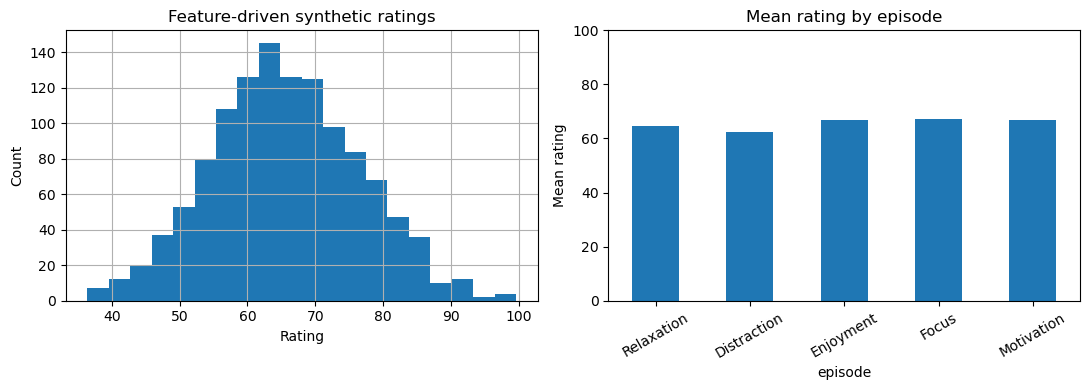

In [7]:
rating_distribution = ratings_df["rating"].describe().rename("rating").reset_index()
episode_means = ratings_df.groupby("episode", observed=False)["rating"].agg(["mean", "std", "count"]).reindex(EPISODE_LEVELS).reset_index()

quartile_rows = []
stimulus_level = feature_df[["stimulus_id", *z_cols]].copy()
for feature in z_cols:
    stimulus_level[f"{feature}_quartile"] = pd.qcut(stimulus_level[feature], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    tmp = ratings_df.merge(stimulus_level[["stimulus_id", f"{feature}_quartile"]], on="stimulus_id", how="left")
    for quartile, value in tmp.groupby(f"{feature}_quartile", observed=False)["rating"].mean().items():
        quartile_rows.append({"feature": feature, "quartile": quartile, "mean_rating": value})
feature_quartile_means = pd.DataFrame(quartile_rows)

selected_feature = "z_SW"
sw_quartiles = stimulus_level[["stimulus_id", f"{selected_feature}_quartile"]].rename(columns={f"{selected_feature}_quartile": "z_SW_quartile"})
episode_sw_quartile_means = (
    ratings_df.merge(sw_quartiles, on="stimulus_id", how="left")
    .groupby(["episode", "z_SW_quartile"], observed=False)["rating"]
    .mean()
    .unstack("z_SW_quartile")
    .reindex(EPISODE_LEVELS)
)
feature_correlation = feature_df[z_cols].corr()

display(rating_distribution.round(3))
display(episode_means.round(3))
display(feature_quartile_means.round(3))
display(episode_sw_quartile_means.round(3))
display(feature_correlation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ratings_df["rating"].hist(ax=axes[0], bins=20)
axes[0].set_title("Feature-driven synthetic ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
episode_means.plot(x="episode", y="mean", kind="bar", ax=axes[1], legend=False)
axes[1].set_title("Mean rating by episode")
axes[1].set_ylabel("Mean rating")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "rating_distribution_and_episode_means.png", dpi=160)
plt.show()

Feature summaries use the twelve unique stimulus vectors as the feature-level support.
The 1,200 repeated rating rows improve rating precision under the synthetic design, but they do not create 1,200 independent acoustic feature observations.

## 8. Prepare Model Data and Priors

In [8]:
model_df = ratings_df.copy()
category_levels = {
    "participant_id": sorted(model_df["participant_id"].unique()),
    "group": ["Group_1", "Group_2"],
    "song_id": SONG_LEVELS,
    "mix_id": MIX_LEVELS,
    "stimulus_id": [f"{song_id}_{mix_id}" for song_id in SONG_LEVELS for mix_id in MIX_LEVELS],
    "episode": EPISODE_LEVELS,
}
for column, levels in category_levels.items():
    model_df[column] = pd.Categorical(model_df[column], categories=levels, ordered=False)

ADDITIVE_FORMULA = "rating ~ episode + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id)"
INTERACTION_FORMULA = "rating ~ episode + z_RMS + z_CF + z_SW + z_SI + episode:z_SW + episode:z_SI + (1 | participant_id)"

COMMON_PRIORS = {
    "Intercept": bmb.Prior("Normal", mu=65, sigma=20),
    "episode": bmb.Prior("Normal", mu=0, sigma=8),
    "z_RMS": bmb.Prior("Normal", mu=0, sigma=8),
    "z_CF": bmb.Prior("Normal", mu=0, sigma=8),
    "z_SW": bmb.Prior("Normal", mu=0, sigma=8),
    "z_SI": bmb.Prior("Normal", mu=0, sigma=8),
    "1|participant_id": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=10)),
    "sigma": bmb.Prior("HalfNormal", sigma=15),
}
INTERACTION_PRIORS = {**COMMON_PRIORS, "episode:z_SW": bmb.Prior("Normal", mu=0, sigma=5), "episode:z_SI": bmb.Prior("Normal", mu=0, sigma=5)}

prior_table = pd.DataFrame(
    [
        {"term": "Intercept", "prior": "Normal(65, 20)", "rating_point_interpretation": "overall rating location on the 0-100 scale"},
        {"term": "episode", "prior": "Normal(0, 8)", "rating_point_interpretation": "episode deviations from Relaxation"},
        {"term": "z_RMS, z_CF, z_SW, z_SI", "prior": "Normal(0, 8)", "rating_point_interpretation": "rating-point change per 1 SD feature increase"},
        {"term": "episode:z_SW, episode:z_SI", "prior": "Normal(0, 5)", "rating_point_interpretation": "additional context-specific rating-point change per 1 SD feature increase"},
        {"term": "participant SD", "prior": "HalfNormal(10)", "rating_point_interpretation": "between-participant intercept variation"},
        {"term": "residual SD", "prior": "HalfNormal(15)", "rating_point_interpretation": "within-cell residual variation"},
    ]
)
model_formula_table = pd.DataFrame(
    [
        {"model": "additive", "formula": ADDITIVE_FORMULA},
        {"model": "reduced_interaction", "formula": INTERACTION_FORMULA},
    ]
)
display(prior_table)
display(model_formula_table)

,term,prior,rating_point_interpretation
0,Intercept,"Normal(65, 20)",overall rating location on the 0-100 scale
1,episode,"Normal(0, 8)",episode deviations from Relaxation
2,"z_RMS, z_CF, z_SW, z_SI","Normal(0, 8)",rating-point change per 1 SD feature increase
3,"episode:z_SW, episode:z_SI","Normal(0, 5)",additional context-specific rating-point chang...
4,participant SD,HalfNormal(10),between-participant intercept variation
5,residual SD,HalfNormal(15),within-cell residual variation


,model,formula
0,additive,rating ~ episode + z_RMS + z_CF + z_SW + z_SI ...
1,reduced_interaction,rating ~ episode + z_RMS + z_CF + z_SW + z_SI ...


## 9. Fit Additive and Reduced Interaction Models

In [9]:
def fit_model(formula: str, priors: dict, label: str):
    model = bmb.Model(formula, model_df, family="gaussian", priors=priors)
    print(model)
    started = time.time()
    idata = model.fit(progressbar=False, **SAMPLING_CONFIG)
    elapsed = time.time() - started
    model.compute_log_likelihood(idata, inplace=True)
    print(f"Finished {label} in {elapsed / 60:.2f} minutes.")
    return model, idata, elapsed

additive_model, additive_idata, additive_elapsed_seconds = fit_model(ADDITIVE_FORMULA, COMMON_PRIORS, "additive feature model")
interaction_model, interaction_idata, interaction_elapsed_seconds = fit_model(INTERACTION_FORMULA, INTERACTION_PRIORS, "reduced interaction feature model")

       Formula: rating ~ episode + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 65.0, sigma: 20.0)
            episode ~ Normal(mu: 0.0, sigma: 8.0)
            z_RMS ~ Normal(mu: 0.0, sigma: 8.0)
            z_CF ~ Normal(mu: 0.0, sigma: 8.0)
            z_SW ~ Normal(mu: 0.0, sigma: 8.0)
            z_SI ~ Normal(mu: 0.0, sigma: 8.0)
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 10.0))
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 15.0)


Finished additive feature model in 0.17 minutes.
       Formula: rating ~ episode + z_RMS + z_CF + z_SW + z_SI + episode:z_SW + episode:z_SI + (1 | participant_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 65.0, sigma: 20.0)
            episode ~ Normal(mu: 0.0, sigma: 8.0)
            z_RMS ~ Normal(mu: 0.0, sigma: 8.0)
            z_CF ~ Normal(mu: 0.0, sigma: 8.0)
            z_SW ~ Normal(mu: 0.0, sigma: 8.0)
            z_SI ~ Normal(mu: 0.0, sigma: 8.0)
            episode:z_SW ~ Normal(mu: 0.0, sigma: 5.0)
            episode:z_SI ~ Normal(mu: 0.0, sigma: 5.0)
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 10.0))
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 15.0)


Finished reduced interaction feature model in 0.09 minutes.


## 10. Model Comparison with PSIS-LOO

In [10]:
additive_loo = az.loo(additive_idata, pointwise=True)
interaction_loo = az.loo(interaction_idata, pointwise=True)
loo_compare = az.compare({"additive": additive_idata, "reduced_interaction": interaction_idata}, ic="loo")

loo_summary = pd.DataFrame(
    [
        {
            "model": "additive",
            "elpd_loo": additive_loo.elpd_loo,
            "se": additive_loo.se,
            "p_loo": additive_loo.p_loo,
            "pareto_k_gt_0_7": int((additive_loo.pareto_k > 0.7).sum()),
            "pareto_k_max": float(additive_loo.pareto_k.max()),
        },
        {
            "model": "reduced_interaction",
            "elpd_loo": interaction_loo.elpd_loo,
            "se": interaction_loo.se,
            "p_loo": interaction_loo.p_loo,
            "pareto_k_gt_0_7": int((interaction_loo.pareto_k > 0.7).sum()),
            "pareto_k_max": float(interaction_loo.pareto_k.max()),
        },
    ]
)
display(loo_summary.round(3))
display(loo_compare.round(3))

,model,elpd_loo,se,p_loo,pareto_k_gt_0_7,pareto_k_max
0,additive,-4293.737,24.703,45.580,0,0.490
1,reduced_interaction,-4282.386,24.632,53.209,0,0.332


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
reduced_interaction,0,-4282.386,53.209,0.000,0.818,24.632,0.000,False,log
additive,1,-4293.737,45.580,11.351,0.182,24.703,6.038,False,log


LOO is used here only to check behaviour under the feature-driven synthetic scenario.
It should not be read as evidence that the same interaction structure will be preferred for real participant data.

## 11. Convergence Diagnostics

,model,divergences,max_rhat,min_bulk_ess,min_tail_ess,max_tree_depth,reached_max_treedepth,finite_energy
0,additive,0,1.01,345.0,720.0,NaN,NaN,True
1,reduced_interaction,0,1.01,353.0,667.0,NaN,NaN,True


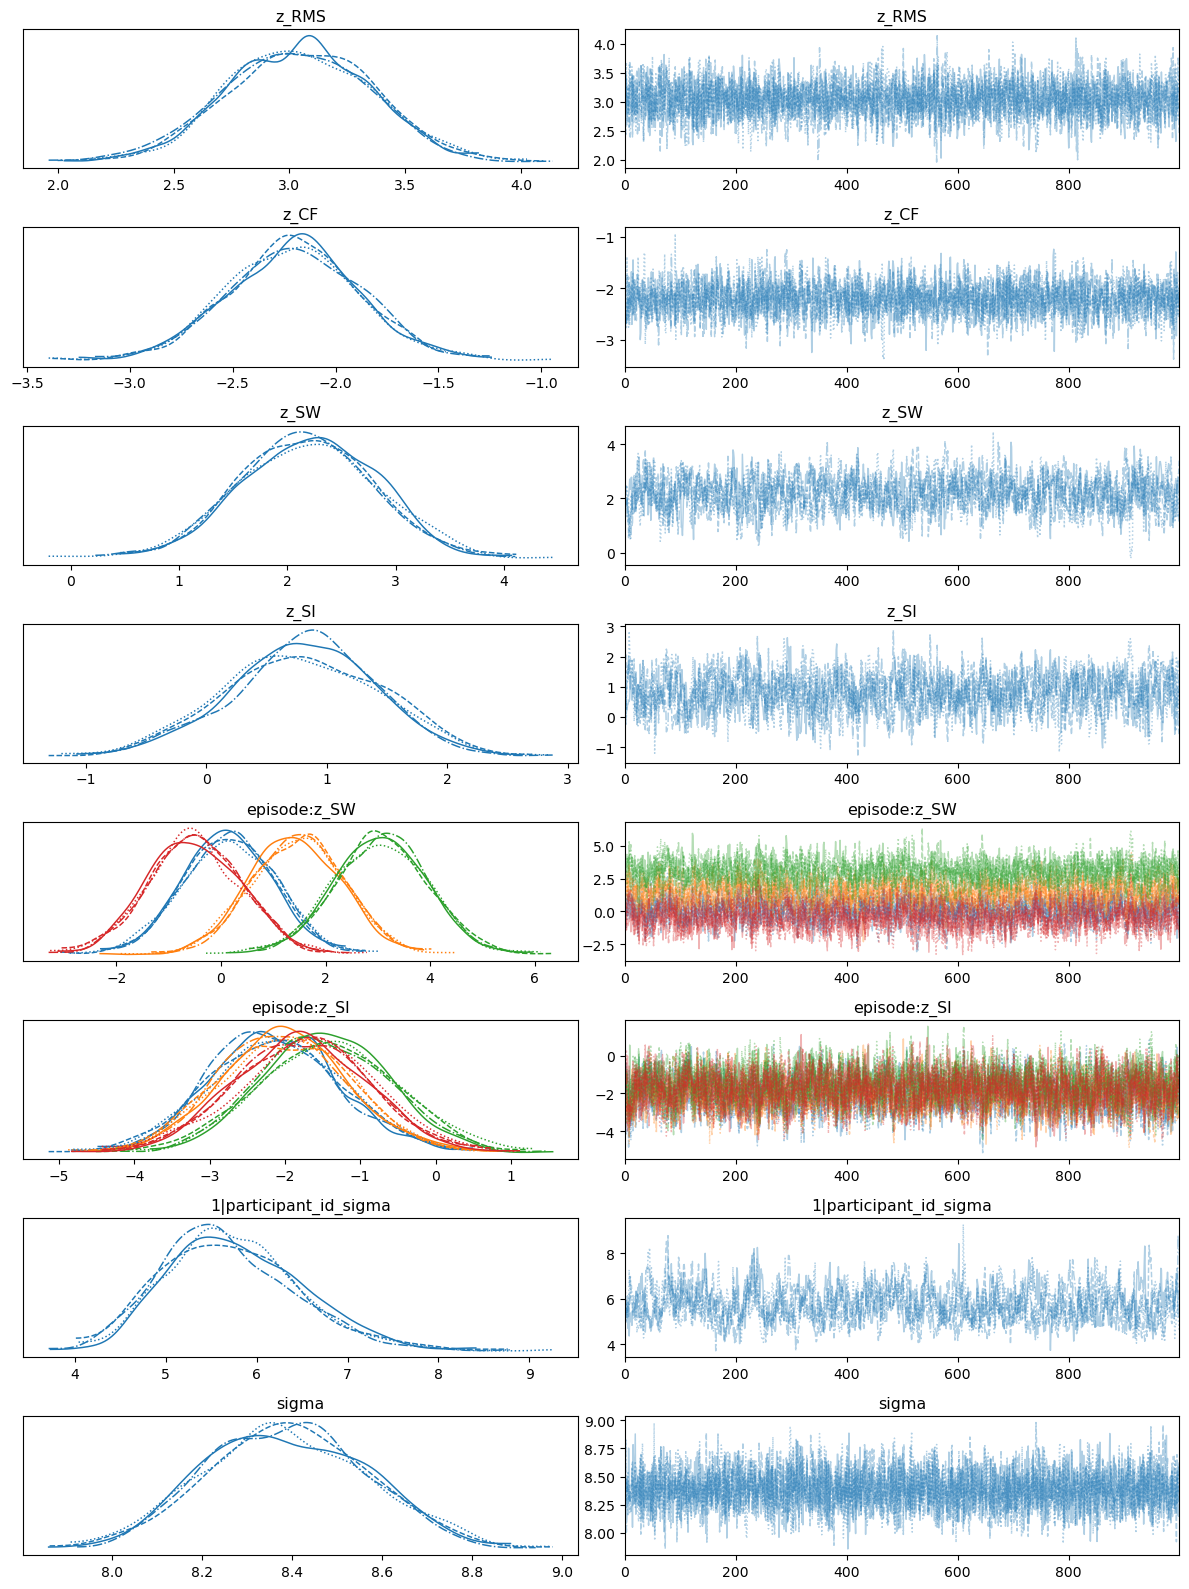

In [11]:
def convergence_table(idata, model_name: str) -> pd.DataFrame:
    summary = az.summary(idata, round_to=None)
    sample_stats = idata.sample_stats
    divergences = int(sample_stats["diverging"].sum().item()) if "diverging" in sample_stats else 0
    max_tree_depth = float(sample_stats["tree_depth"].max().item()) if "tree_depth" in sample_stats else np.nan
    reached_max_treedepth = int(sample_stats["reached_max_treedepth"].sum().item()) if "reached_max_treedepth" in sample_stats else np.nan
    energy_warning = bool(np.isfinite(sample_stats["energy"].values).all()) if "energy" in sample_stats else np.nan
    return pd.DataFrame(
        [
            {
                "model": model_name,
                "divergences": divergences,
                "max_rhat": float(summary["r_hat"].max(skipna=True)),
                "min_bulk_ess": float(summary["ess_bulk"].min(skipna=True)),
                "min_tail_ess": float(summary["ess_tail"].min(skipna=True)),
                "max_tree_depth": max_tree_depth,
                "reached_max_treedepth": reached_max_treedepth,
                "finite_energy": energy_warning,
            }
        ]
    )

additive_summary = az.summary(additive_idata, round_to=None)
interaction_summary = az.summary(interaction_idata, round_to=None)
diagnostics_df = pd.concat(
    [convergence_table(additive_idata, "additive"), convergence_table(interaction_idata, "reduced_interaction")],
    ignore_index=True,
)
display(diagnostics_df.round(3))

trace_candidates = ["z_RMS", "z_CF", "z_SW", "z_SI", "episode:z_SW", "episode:z_SI", "1|participant_id_sigma", "sigma"]
trace_vars = [var for var in trace_candidates if var in interaction_idata.posterior]
az.plot_trace(interaction_idata, var_names=trace_vars, compact=True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "interaction_model_selected_traces.png", dpi=160)
plt.show()

## 12. Posterior Predictive Checks

In [12]:
def posterior_predictive_summary(model, idata, source_df: pd.DataFrame, model_name: str):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ppc_idata = model.predict(
            idata,
            kind="response",
            inplace=False,
            include_group_specific=True,
            random_seed=SEED,
        )
    yrep = ppc_idata.posterior_predictive["rating"].values
    yrep_2d = yrep.reshape(-1, yrep.shape[-1])
    boundary_rate = float(((yrep_2d < 0) | (yrep_2d > 100)).mean())

    obs_mean = float(source_df["rating"].mean())
    obs_sd = float(source_df["rating"].std())
    rep_mean = yrep_2d.mean(axis=1)
    rep_sd = yrep_2d.std(axis=1)

    rows = [
        {"model": model_name, "quantity": "overall_mean", "observed": obs_mean, "ppc_mean": rep_mean.mean(), "hdi_3%": np.quantile(rep_mean, 0.03), "hdi_97%": np.quantile(rep_mean, 0.97)},
        {"model": model_name, "quantity": "overall_sd", "observed": obs_sd, "ppc_mean": rep_sd.mean(), "hdi_3%": np.quantile(rep_sd, 0.03), "hdi_97%": np.quantile(rep_sd, 0.97)},
        {"model": model_name, "quantity": "ppc_outside_0_100_proportion", "observed": 0.0, "ppc_mean": boundary_rate, "hdi_3%": np.nan, "hdi_97%": np.nan},
    ]

    for group_col, prefix in [("episode", "episode_mean"), ("stimulus_id", "stimulus_mean")]:
        for level, indices in source_df.groupby(group_col, observed=False).indices.items():
            idx = np.asarray(indices)
            rep_group_mean = yrep_2d[:, idx].mean(axis=1)
            rows.append(
                {
                    "model": model_name,
                    "quantity": f"{prefix}:{level}",
                    "observed": float(source_df.iloc[idx]["rating"].mean()),
                    "ppc_mean": rep_group_mean.mean(),
                    "hdi_3%": np.quantile(rep_group_mean, 0.03),
                    "hdi_97%": np.quantile(rep_group_mean, 0.97),
                }
            )
    return pd.DataFrame(rows), ppc_idata

additive_ppc_summary, additive_ppc_idata = posterior_predictive_summary(additive_model, additive_idata, model_df, "additive")
interaction_ppc_summary, interaction_ppc_idata = posterior_predictive_summary(interaction_model, interaction_idata, model_df, "reduced_interaction")
ppc_summary = pd.concat([additive_ppc_summary, interaction_ppc_summary], ignore_index=True)
display(ppc_summary[ppc_summary["quantity"].isin(["overall_mean", "overall_sd", "ppc_outside_0_100_proportion"])].round(4))
display(ppc_summary[ppc_summary["quantity"].str.startswith("episode_mean")].round(3))

,model,quantity,observed,ppc_mean,hdi_3%,hdi_97%
0,additive,overall_mean,65.6048,65.6043,64.9438,66.2390
1,additive,overall_sd,10.9144,10.9511,10.4179,11.4901
2,additive,ppc_outside_0_100_proportion,0.0000,0.0007,NaN,NaN
20,reduced_interaction,overall_mean,65.6048,65.6121,64.9803,66.2607
21,reduced_interaction,overall_sd,10.9144,10.9829,10.4284,11.5202
22,reduced_interaction,ppc_outside_0_100_proportion,0.0000,0.0008,NaN,NaN


,model,quantity,observed,ppc_mean,hdi_3%,hdi_97%
3,additive,episode_mean:Relaxation,64.574,64.567,63.104,66.030
4,additive,episode_mean:Distraction,62.422,62.489,61.008,63.969
5,additive,episode_mean:Enjoyment,66.990,66.963,65.473,68.374
6,additive,episode_mean:Focus,67.232,67.206,65.752,68.683
7,additive,episode_mean:Motivation,66.806,66.797,65.322,68.222
23,reduced_interaction,episode_mean:Relaxation,64.574,64.571,63.164,66.015
24,reduced_interaction,episode_mean:Distraction,62.422,62.503,61.054,63.926
25,reduced_interaction,episode_mean:Enjoyment,66.990,66.967,65.557,68.406
26,reduced_interaction,episode_mean:Focus,67.232,67.210,65.750,68.631
27,reduced_interaction,episode_mean:Motivation,66.806,66.809,65.403,68.295


## 13. Effect Recovery: Coefficients

In [13]:
extracted_posterior = az.extract(interaction_idata, group="posterior", combined=True)

def scalar_draws(var_name: str) -> np.ndarray:
    return np.asarray(extracted_posterior[var_name]).reshape(-1)

def indexed_draws(var_name: str, level: str) -> np.ndarray:
    da = extracted_posterior[var_name]
    non_sample_dims = [dim for dim in da.dims if dim != "sample"]
    if len(non_sample_dims) != 1:
        raise ValueError(f"Expected one non-sample dimension for {var_name}; found {da.dims}")
    dim = non_sample_dims[0]
    labels = [str(value) for value in da[dim].values]
    if level not in labels:
        return np.zeros(extracted_posterior.sizes["sample"])
    return np.asarray(da.isel({dim: labels.index(level)})).reshape(-1)

def summarise_recovery(quantity: str, posterior_draws: np.ndarray, true_value: float, parameterisation: str) -> dict:
    hdi = az.hdi(posterior_draws, hdi_prob=0.94)
    mean_value = float(np.mean(posterior_draws))
    return {
        "quantity": quantity,
        "parameterisation": parameterisation,
        "true_value": true_value,
        "posterior_mean": mean_value,
        "hdi_3%": float(hdi[0]),
        "hdi_97%": float(hdi[1]),
        "absolute_error": abs(mean_value - true_value),
        "credible_interval_contains_true": bool(hdi[0] <= true_value <= hdi[1]),
    }

coefficient_rows = [
    summarise_recovery("z_RMS_main_slope", scalar_draws("z_RMS"), FEATURE_MAIN_EFFECTS["z_RMS"], "direct coefficient"),
    summarise_recovery("z_CF_main_slope", scalar_draws("z_CF"), FEATURE_MAIN_EFFECTS["z_CF"], "direct coefficient"),
]

for episode in EPISODE_LEVELS:
    true_sw_slope = FEATURE_MAIN_EFFECTS["z_SW"] + FEATURE_INTERACTIONS.get((episode, "z_SW"), 0.0)
    true_si_slope = FEATURE_MAIN_EFFECTS["z_SI"] + FEATURE_INTERACTIONS.get((episode, "z_SI"), 0.0)
    coefficient_rows.append(
        summarise_recovery(
            f"z_SW_slope_in_{episode}",
            scalar_draws("z_SW") + indexed_draws("episode:z_SW", episode),
            true_sw_slope,
            "derived model-implied episode-specific slope",
        )
    )
    coefficient_rows.append(
        summarise_recovery(
            f"z_SI_slope_in_{episode}",
            scalar_draws("z_SI") + indexed_draws("episode:z_SI", episode),
            true_si_slope,
            "derived model-implied episode-specific slope",
        )
    )

coefficient_recovery_df = pd.DataFrame(coefficient_rows)
display(coefficient_recovery_df.round(3))

,quantity,parameterisation,true_value,posterior_mean,hdi_3%,hdi_97%,absolute_error,credible_interval_contains_true
0,z_RMS_main_slope,direct coefficient,2.5,3.039,2.470,3.622,0.539,True
1,z_CF_main_slope,direct coefficient,-1.8,-2.207,-2.790,-1.615,0.407,True
2,z_SW_slope_in_Relaxation,derived model-implied episode-specific slope,2.2,1.677,0.448,2.881,0.523,True
3,z_SI_slope_in_Relaxation,derived model-implied episode-specific slope,-1.2,-0.970,-2.252,0.306,0.230,True
4,z_SW_slope_in_Distraction,derived model-implied episode-specific slope,2.2,2.183,1.038,3.359,0.017,True
5,z_SI_slope_in_Distraction,derived model-implied episode-specific slope,0.6,0.800,-0.398,1.925,0.200,True
6,z_SW_slope_in_Enjoyment,derived model-implied episode-specific slope,2.2,2.332,1.094,3.445,0.132,True
7,z_SI_slope_in_Enjoyment,derived model-implied episode-specific slope,-1.2,-1.326,-2.567,-0.169,0.126,True
8,z_SW_slope_in_Focus,derived model-implied episode-specific slope,4.2,3.639,2.474,4.884,0.561,True
9,z_SI_slope_in_Focus,derived model-implied episode-specific slope,-1.2,-1.208,-2.469,-0.017,0.008,True


## 14. Effect Recovery: Episode x Stimulus Cell Means

In [14]:
prediction_grid = pd.DataFrame(
    [(episode, song_id, mix_id) for episode in EPISODE_LEVELS for song_id in SONG_LEVELS for mix_id in MIX_LEVELS],
    columns=["episode", "song_id", "mix_id"],
).merge(feature_df[["song_id", "mix_id", "stimulus_id", *z_cols]], on=["song_id", "mix_id"], how="left")
prediction_grid["participant_id"] = category_levels["participant_id"][0]
prediction_grid["group"] = np.where(prediction_grid["song_id"].isin(GROUP_SONGS["Group_1"]), "Group_1", "Group_2")
for column, levels in category_levels.items():
    prediction_grid[column] = pd.Categorical(prediction_grid[column], categories=levels, ordered=False)

cell_mean_idata = interaction_model.predict(
    interaction_idata,
    kind="response_params",
    data=prediction_grid,
    inplace=False,
    include_group_specific=False,
)
mu_draws = cell_mean_idata.posterior["mu"].values
mu_cell_draws = mu_draws.reshape(-1, mu_draws.shape[-1])
true_cell_means = prediction_grid.apply(population_expected_rating, axis=1).to_numpy()
posterior_cell_mean = mu_cell_draws.mean(axis=0)
cell_hdi = az.hdi(mu_cell_draws, hdi_prob=0.94)

cell_recovery_df = prediction_grid[["song_id", "episode", "stimulus_id", "mix_id", *z_cols]].copy()
cell_recovery_df["true_expected_cell_mean"] = true_cell_means
cell_recovery_df["posterior_predicted_mean"] = posterior_cell_mean
cell_recovery_df["hdi_3%"] = cell_hdi[:, 0]
cell_recovery_df["hdi_97%"] = cell_hdi[:, 1]
cell_recovery_df["absolute_error"] = (cell_recovery_df["posterior_predicted_mean"] - cell_recovery_df["true_expected_cell_mean"]).abs()
cell_recovery_df["covered_by_94pct_hdi"] = cell_recovery_df["true_expected_cell_mean"].between(cell_recovery_df["hdi_3%"], cell_recovery_df["hdi_97%"])
cell_mean_rmse = float(np.sqrt(np.mean((cell_recovery_df["posterior_predicted_mean"] - cell_recovery_df["true_expected_cell_mean"]) ** 2)))
cell_mean_coverage = float(cell_recovery_df["covered_by_94pct_hdi"].mean())
cell_recovery_summary = pd.DataFrame(
    [{"metric": "cell_mean_RMSE", "value": cell_mean_rmse}, {"metric": "94pct_HDI_coverage", "value": cell_mean_coverage}]
)
display(cell_recovery_summary.round(4))
display(cell_recovery_df.round(3).head(15))

C:\Users\oscar\AppData\Local\Temp\ipykernel_7064\3199959447.py:21: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  cell_hdi = az.hdi(mu_cell_draws, hdi_prob=0.94)


,metric,value
0,cell_mean_RMSE,1.9458
1,94pct_HDI_coverage,0.8000


,song_id,episode,stimulus_id,mix_id,z_RMS,z_CF,z_SW,z_SI,true_expected_cell_mean,posterior_predicted_mean,hdi_3%,hdi_97%,absolute_error,covered_by_94pct_hdi
0,Song_1,Relaxation,Song_1_Mix_1,Mix_1,1.443,0.786,-0.541,-0.499,64.602,66.776,64.659,69.046,2.175,False
1,Song_1,Relaxation,Song_1_Mix_2,Mix_2,0.373,-0.175,-1.303,-0.429,61.896,64.298,61.739,66.682,2.402,True
2,Song_1,Relaxation,Song_1_Mix_3,Mix_3,0.936,-1.971,0.040,-0.659,69.767,72.448,70.055,75.073,2.681,False
3,Song_2,Relaxation,Song_2_Mix_1,Mix_1,-0.740,-0.873,-0.802,-0.197,61.194,63.070,60.761,65.328,1.877,True
4,Song_2,Relaxation,Song_2_Mix_2,Mix_2,-1.855,0.230,0.262,0.391,58.056,58.462,56.102,60.622,0.405,True
5,Song_2,Relaxation,Song_2_Mix_3,Mix_3,-1.426,-1.617,1.805,0.231,66.039,66.582,63.672,69.642,0.543,True
6,Song_3,Relaxation,Song_3_Mix_1,Mix_1,-0.270,-0.132,-0.326,-0.460,62.397,63.917,61.844,65.983,1.520,True
7,Song_3,Relaxation,Song_3_Mix_2,Mix_2,-0.712,0.581,1.418,3.144,59.522,60.427,56.859,64.779,0.906,True
8,Song_3,Relaxation,Song_3_Mix_3,Mix_3,-0.133,0.084,-1.524,-0.350,59.584,61.741,59.067,64.379,2.158,True
9,Song_4,Relaxation,Song_4_Mix_1,Mix_1,0.400,0.924,1.059,-0.023,64.694,65.521,62.917,67.826,0.827,True


## 15. Multicollinearity and Posterior Dependence

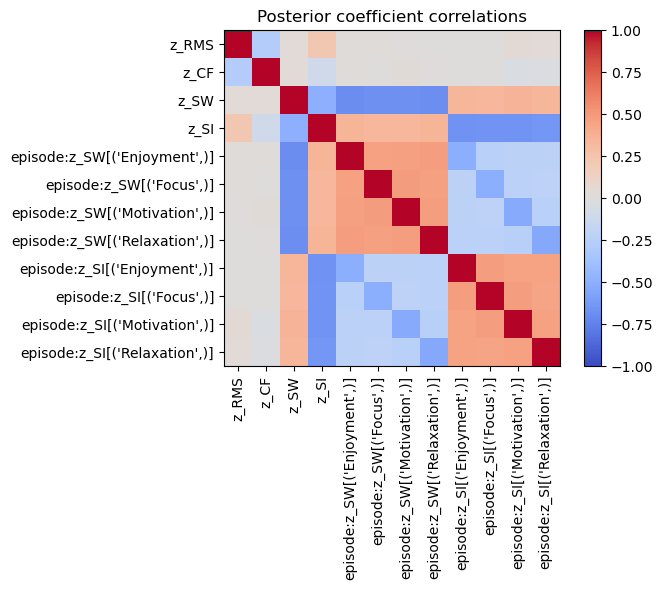

,feature,stimulus_level_r2,stimulus_level_vif
0,z_RMS,0.360,1.563
1,z_CF,0.188,1.231
2,z_SW,0.329,1.490
3,z_SI,0.456,1.839


,coefficient_a,coefficient_b,correlation,abs_correlation
25,z_SW,"episode:z_SW[('Enjoyment',)]",-0.693,0.693
79,"episode:z_SW[('Relaxation',)]",z_SW,-0.680,0.680
57,"episode:z_SW[('Focus',)]",z_SW,-0.677,0.677
27,z_SW,"episode:z_SW[('Motivation',)]",-0.677,0.677
40,z_SI,"episode:z_SI[('Enjoyment',)]",-0.661,0.661
42,z_SI,"episode:z_SI[('Motivation',)]",-0.651,0.651
41,z_SI,"episode:z_SI[('Focus',)]",-0.650,0.650
43,z_SI,"episode:z_SI[('Relaxation',)]",-0.639,0.639
87,"episode:z_SW[('Relaxation',)]","episode:z_SI[('Relaxation',)]",-0.541,0.541
116,"episode:z_SI[('Motivation',)]","episode:z_SW[('Motivation',)]",-0.529,0.529


In [15]:
def posterior_coefficients_to_frame(idata) -> pd.DataFrame:
    extracted = az.extract(idata, group="posterior", combined=True)
    frames = []
    for var_name in extracted.data_vars:
        if not any(token in var_name for token in ["z_RMS", "z_CF", "z_SW", "z_SI", "episode:z_SW", "episode:z_SI"]):
            continue
        da = extracted[var_name]
        if da.ndim == 1:
            frames.append(pd.Series(da.values, name=var_name))
        else:
            non_sample_dims = [dim for dim in da.dims if dim != "sample"]
            stacked = da.stack(term=non_sample_dims).transpose("sample", "term")
            for term in stacked.term.values:
                label = f"{var_name}[{term}]"
                frames.append(pd.Series(stacked.sel(term=term).values, name=label))
    return pd.concat(frames, axis=1)

coefficient_draws = posterior_coefficients_to_frame(interaction_idata)
posterior_coefficient_correlation = coefficient_draws.corr()
strongest_corr = (
    posterior_coefficient_correlation.where(~np.eye(len(posterior_coefficient_correlation), dtype=bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "coefficient_a", "level_1": "coefficient_b"})
)
strongest_corr["abs_correlation"] = strongest_corr["correlation"].abs()
strongest_corr = strongest_corr.sort_values("abs_correlation", ascending=False).drop_duplicates("abs_correlation").head(12)

def vif_on_unique_stimuli(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []
    x = df[features].to_numpy()
    for i, feature in enumerate(features):
        y = x[:, i]
        x_other = np.delete(x, i, axis=1)
        x_design = np.column_stack([np.ones(len(x_other)), x_other])
        beta, *_ = np.linalg.lstsq(x_design, y, rcond=None)
        fitted = x_design @ beta
        ss_res = float(((y - fitted) ** 2).sum())
        ss_tot = float(((y - y.mean()) ** 2).sum())
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        rows.append({"feature": feature, "stimulus_level_r2": r2, "stimulus_level_vif": 1 / (1 - r2) if r2 < 1 else np.inf})
    return pd.DataFrame(rows)

vif_df = vif_on_unique_stimuli(feature_df, z_cols)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(posterior_coefficient_correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(posterior_coefficient_correlation.columns)))
ax.set_xticklabels(posterior_coefficient_correlation.columns, rotation=90)
ax.set_yticks(range(len(posterior_coefficient_correlation.index)))
ax.set_yticklabels(posterior_coefficient_correlation.index)
ax.set_title("Posterior coefficient correlations")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "posterior_coefficient_correlations.png", dpi=160)
plt.show()

display(vif_df.round(3))
display(strongest_corr.round(3))

The VIF calculation above is based on the twelve unique stimulus feature vectors, not the 1,200 repeated rating rows.
Even this stimulus-level VIF is only a rough diagnostic because there are very few independent feature combinations.

## 16. Posterior Highest-Rated Mix Prediction

In [16]:
prediction_rows = []
prediction_validation_rows = []

for episode in EPISODE_LEVELS:
    for song_id in SONG_LEVELS:
        song_mask = (prediction_grid["episode"].astype(str).eq(episode)) & (prediction_grid["song_id"].astype(str).eq(song_id))
        song_grid_index = np.flatnonzero(song_mask.to_numpy())
        song_draws = mu_cell_draws[:, song_grid_index]
        if song_draws.shape[1] != 3:
            raise ValueError(f"Expected 3 candidate stimuli for {song_id} x {episode}; found {song_draws.shape[1]}.")

        draw_max = song_draws.max(axis=1, keepdims=True)
        draw_winner_mask = np.isclose(song_draws, draw_max, rtol=0.0, atol=1e-12)
        draw_tie_mask = draw_winner_mask.sum(axis=1) > 1
        draw_winner_weights = draw_winner_mask / draw_winner_mask.sum(axis=1, keepdims=True)
        posterior_probabilities = draw_winner_weights.mean(axis=0)
        posterior_tie_probability = float(draw_tie_mask.mean())

        posterior_means = song_draws.mean(axis=0)
        hdi = az.hdi(song_draws, hdi_prob=0.94)

        max_probability = posterior_probabilities.max()
        final_probability_tie_mask = np.isclose(posterior_probabilities, max_probability, rtol=0.0, atol=1e-12)
        has_final_probability_tie = bool(final_probability_tie_mask.sum() > 1)
        final_winner_local = int(np.flatnonzero(final_probability_tie_mask)[0]) if has_final_probability_tie else int(np.argmax(posterior_probabilities))

        prediction_validation_rows.append(
            {
                "song_id": song_id,
                "episode": episode,
                "candidate_stimuli": int(song_draws.shape[1]),
                "probability_sum": float(posterior_probabilities.sum()),
                "probabilities_between_0_and_1": bool(((posterior_probabilities >= 0) & (posterior_probabilities <= 1)).all()),
                "final_probability_tie": has_final_probability_tie,
                "draw_level_tie_probability": posterior_tie_probability,
            }
        )

        for local_index, grid_index in enumerate(song_grid_index):
            row = prediction_grid.iloc[grid_index]
            prediction_rows.append(
                {
                    "song_id": song_id,
                    "episode": episode,
                    "stimulus_id": row["stimulus_id"],
                    "mix_id": row["mix_id"],
                    "posterior_mean_rating": posterior_means[local_index],
                    "hdi_3%": hdi[local_index, 0],
                    "hdi_97%": hdi[local_index, 1],
                    "posterior_probability_highest": float(posterior_probabilities[local_index]),
                    "is_final_predicted_winner": bool(local_index == final_winner_local),
                    "final_probability_tie": has_final_probability_tie,
                    "draw_level_tie_probability": posterior_tie_probability,
                }
            )

predicted_highest_df = pd.DataFrame(prediction_rows)
prediction_validation_df = pd.DataFrame(prediction_validation_rows)
winner_validation_df = pd.DataFrame(
    [
        {
            "check": "three_candidate_stimuli_per_song_episode",
            "passed": prediction_validation_df["candidate_stimuli"].eq(3).all(),
            "observed": prediction_validation_df["candidate_stimuli"].unique().tolist(),
            "expected": 3,
        },
        {
            "check": "probabilities_between_0_and_1",
            "passed": prediction_validation_df["probabilities_between_0_and_1"].all(),
            "observed": "all checked",
            "expected": "0 <= probability <= 1",
        },
        {
            "check": "probabilities_sum_to_approximately_1",
            "passed": np.isclose(prediction_validation_df["probability_sum"], 1.0, atol=1e-10).all(),
            "observed": prediction_validation_df["probability_sum"].round(12).unique().tolist(),
            "expected": 1.0,
        },
        {
            "check": "one_final_winner_per_song_episode",
            "passed": predicted_highest_df.groupby(["song_id", "episode"])["is_final_predicted_winner"].sum().eq(1).all(),
            "observed": predicted_highest_df.groupby(["song_id", "episode"])["is_final_predicted_winner"].sum().unique().tolist(),
            "expected": 1,
        },
    ]
)
display(predicted_highest_df.round(4).head(18))
display(prediction_validation_df.round(6))
display(winner_validation_df)
assert winner_validation_df["passed"].all()

C:\Users\oscar\AppData\Local\Temp\ipykernel_7064\23476320.py:20: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(song_draws, hdi_prob=0.94)
C:\Users\oscar\AppData\Local\Temp\ipykernel_7064\23476320.py:20: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(song_draws, hdi_prob=0.94)
C:\Users\oscar\AppData\Local\Temp\ipykernel_7064\23476320.py:20: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(song_draws, hdi_prob=0.94)
C:\Users\oscar\AppData\Local\Temp\ipykernel_7064\23476320.py:20: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence wit

,song_id,episode,stimulus_id,mix_id,posterior_mean_rating,hdi_3%,hdi_97%,posterior_probability_highest,is_final_predicted_winner,final_probability_tie,draw_level_tie_probability
0,Song_1,Relaxation,Song_1_Mix_1,Mix_1,66.7765,64.6593,69.0456,0.0000,False,False,0.0
1,Song_1,Relaxation,Song_1_Mix_2,Mix_2,64.2978,61.7388,66.6823,0.0000,False,False,0.0
2,Song_1,Relaxation,Song_1_Mix_3,Mix_3,72.4479,70.0552,75.0725,1.0000,True,False,0.0
3,Song_2,Relaxation,Song_2_Mix_1,Mix_1,63.0705,60.7612,65.3283,0.0092,False,False,0.0
4,Song_2,Relaxation,Song_2_Mix_2,Mix_2,58.4615,56.1017,60.6221,0.0000,False,False,0.0
5,Song_2,Relaxation,Song_2_Mix_3,Mix_3,66.5825,63.6719,69.6422,0.9908,True,False,0.0
6,Song_3,Relaxation,Song_3_Mix_1,Mix_1,63.9166,61.8438,65.9826,0.9508,True,False,0.0
7,Song_3,Relaxation,Song_3_Mix_2,Mix_2,60.4275,56.8587,64.7786,0.0468,False,False,0.0
8,Song_3,Relaxation,Song_3_Mix_3,Mix_3,61.7415,59.0671,64.3785,0.0025,False,False,0.0
9,Song_4,Relaxation,Song_4_Mix_1,Mix_1,65.5212,62.9169,67.8260,0.0760,False,False,0.0


,song_id,episode,candidate_stimuli,probability_sum,probabilities_between_0_and_1,final_probability_tie,draw_level_tie_probability
0,Song_1,Relaxation,3,1.0,True,False,0.0
1,Song_2,Relaxation,3,1.0,True,False,0.0
2,Song_3,Relaxation,3,1.0,True,False,0.0
3,Song_4,Relaxation,3,1.0,True,False,0.0
4,Song_1,Distraction,3,1.0,True,False,0.0
5,Song_2,Distraction,3,1.0,True,False,0.0
6,Song_3,Distraction,3,1.0,True,False,0.0
7,Song_4,Distraction,3,1.0,True,False,0.0
8,Song_1,Enjoyment,3,1.0,True,False,0.0
9,Song_2,Enjoyment,3,1.0,True,False,0.0


,check,passed,observed,expected
0,three_candidate_stimuli_per_song_episode,True,[3],3
1,probabilities_between_0_and_1,True,all checked,0 <= probability <= 1
2,probabilities_sum_to_approximately_1,True,[1.0],1.0
3,one_final_winner_per_song_episode,True,[1],1


## 17. Methodological Comparison with the Categorical Baseline

In [17]:
categorical_predictions = pd.read_csv(CATEGORICAL_PREDICTION_PATH)
methodological_comparison = pd.DataFrame(
    [
        {
            "baseline": "categorical stimulus model",
            "synthetic_outcome_source": "Notebook 1 categorical Episode x Mix / Episode x Stimulus assumptions",
            "predictors": "episode * stimulus_id + participant random intercept",
            "parameterisation": "many stimulus-specific effects",
            "ability_to_explain_preference": "captures observed stimulus differences but does not explain them through features",
            "ability_to_generalise_to_new_stimuli": "limited without new stimulus levels and ratings",
            "main_limitation": "not an acoustic-feature recovery analysis",
        },
        {
            "baseline": "feature-based model",
            "synthetic_outcome_source": "new feature-driven simulation using real twelve-stimulus feature vectors",
            "predictors": "episode + z_RMS + z_CF + z_SW + z_SI, with a small SW/SI interaction sensitivity model",
            "parameterisation": "fewer interpretable feature coefficients",
            "ability_to_explain_preference": "links predicted ratings to objective feature covariates under the hypothetical DGP",
            "ability_to_generalise_to_new_stimuli": "potentially better if future stimuli have the same features measured",
            "main_limitation": "only twelve feature vectors, so feature effects can be weakly identified and correlated",
        },
    ]
)
display(categorical_predictions.head())
display(methodological_comparison)

,song_id,episode,stimulus_id,mix_id,posterior_mean_rating,hdi_3%,hdi_97%,posterior_probability_highest,is_final_predicted_winner,final_probability_tie,draw_level_tie_probability
0,Song_1,Relaxation,Song_1_Mix_1,Mix_1,64.8313,60.1726,70.2765,0.6992,True,False,0.0
1,Song_1,Relaxation,Song_1_Mix_2,Mix_2,63.1919,58.2132,68.0115,0.2990,False,False,0.0
2,Song_1,Relaxation,Song_1_Mix_3,Mix_3,56.8971,51.5722,61.6551,0.0018,False,False,0.0
3,Song_2,Relaxation,Song_2_Mix_1,Mix_1,64.7012,59.7385,69.6333,0.1968,False,False,0.0
4,Song_2,Relaxation,Song_2_Mix_2,Mix_2,67.1283,62.3259,72.4710,0.7710,True,False,0.0


,baseline,synthetic_outcome_source,predictors,parameterisation,ability_to_explain_preference,ability_to_generalise_to_new_stimuli,main_limitation
0,categorical stimulus model,Notebook 1 categorical Episode x Mix / Episode...,episode * stimulus_id + participant random int...,many stimulus-specific effects,captures observed stimulus differences but doe...,limited without new stimulus levels and ratings,not an acoustic-feature recovery analysis
1,feature-based model,new feature-driven simulation using real twelv...,"episode + z_RMS + z_CF + z_SW + z_SI, with a s...",fewer interpretable feature coefficients,links predicted ratings to objective feature c...,potentially better if future stimuli have the ...,"only twelve feature vectors, so feature effect..."


## 18. Export Outputs

In [18]:
simulation_parameters.to_csv(OUTPUT_DIR / "simulation_parameter_table.csv", index=False)
data_validation_df.to_csv(OUTPUT_DIR / "feature_driven_dataset_validation.csv", index=False)
ratings_df.describe(include="all").transpose().reset_index().to_csv(OUTPUT_DIR / "feature_driven_synthetic_dataset_summary.csv", index=False)
model_formula_table.to_csv(OUTPUT_DIR / "model_formulas.csv", index=False)
prior_table.to_csv(OUTPUT_DIR / "model_priors.csv", index=False)
additive_summary.to_csv(OUTPUT_DIR / "posterior_summary_additive.csv")
interaction_summary.to_csv(OUTPUT_DIR / "posterior_summary_reduced_interaction.csv")
diagnostics_df.to_csv(OUTPUT_DIR / "convergence_diagnostics.csv", index=False)
loo_summary.to_csv(OUTPUT_DIR / "loo_summary.csv", index=False)
loo_compare.to_csv(OUTPUT_DIR / "loo_compare.csv")
ppc_summary.to_csv(OUTPUT_DIR / "posterior_predictive_summary.csv", index=False)
coefficient_recovery_df.to_csv(OUTPUT_DIR / "coefficient_recovery_table.csv", index=False)
cell_recovery_df.to_csv(OUTPUT_DIR / "cell_mean_recovery_table.csv", index=False)
posterior_coefficient_correlation.to_csv(OUTPUT_DIR / "posterior_coefficient_correlations.csv")
strongest_corr.to_csv(OUTPUT_DIR / "strongest_posterior_coefficient_correlations.csv", index=False)
vif_df.to_csv(OUTPUT_DIR / "stimulus_level_vif.csv", index=False)
predicted_highest_df.round(4).to_csv(OUTPUT_DIR / "predicted_highest_rated_mixes.csv", index=False)
prediction_validation_df.to_csv(OUTPUT_DIR / "posterior_winner_validation.csv", index=False)
methodological_comparison.to_csv(OUTPUT_DIR / "methodological_comparison_with_categorical_baseline.csv", index=False)

def make_netcdf_attrs_serializable(idata):
    def clean_attrs(attrs):
        cleaned = {}
        for key, value in attrs.items():
            if isinstance(value, (str, bytes, int, float, np.number, np.ndarray, list, tuple)):
                cleaned[key] = value
            else:
                cleaned[key] = json.dumps(value, default=str)
        return cleaned

    idata.attrs = clean_attrs(idata.attrs)
    for group_name in idata.groups():
        group = getattr(idata, group_name)
        group.attrs = clean_attrs(group.attrs)
    return idata

make_netcdf_attrs_serializable(additive_idata).to_netcdf(OUTPUT_DIR / "additive_feature_model_idata.nc")
make_netcdf_attrs_serializable(interaction_idata).to_netcdf(OUTPUT_DIR / "reduced_interaction_feature_model_idata.nc")

export_manifest = pd.DataFrame(
    [{"file": path.name, "path": str(path.relative_to(REPO_ROOT))} for path in sorted(OUTPUT_DIR.glob("*")) if path.is_file()]
)
display(export_manifest)

,file,path
0,additive_feature_model_idata.nc,outputs\statistical_baseline\feature_based_mod...
1,cell_mean_recovery_table.csv,outputs\statistical_baseline\feature_based_mod...
2,coefficient_recovery_table.csv,outputs\statistical_baseline\feature_based_mod...
3,convergence_diagnostics.csv,outputs\statistical_baseline\feature_based_mod...
4,execution_summary.csv,outputs\statistical_baseline\feature_based_mod...
5,feature_driven_dataset_validation.csv,outputs\statistical_baseline\feature_based_mod...
6,feature_driven_synthetic_dataset_summary.csv,outputs\statistical_baseline\feature_based_mod...
7,loo_compare.csv,outputs\statistical_baseline\feature_based_mod...
8,loo_summary.csv,outputs\statistical_baseline\feature_based_mod...
9,methodological_comparison_with_categorical_bas...,outputs\statistical_baseline\feature_based_mod...


## 19. Recommended Feature-Based Baseline for Real Data

For real participant ratings, the provisional starting model should be:

`rating ~ episode + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id)`

Interactions should not be added as a default first model. A small pre-specified or explicitly model-compared interaction structure can be considered after the additive model is checked, because all possible Episode x Feature interactions would be high-dimensional relative to the twelve unique stimulus feature vectors.

BS is excluded from the primary feature baseline because Notebook 3 found no defensible scalar BS predictor, and the available Bark PCA scores are within-song selection diagnostics rather than a simple global acoustic construct.

The twelve selected stimuli limit feature-effect identification. Feature coefficients should therefore be interpreted cautiously as associations within this stimulus set, not causal acoustic effects. Participant-level cross-validation remains required before using the feature baseline for real-data prediction or power simulations.

## 20. Execution Summary

In [19]:
winner_probability_sum_ok = bool(np.isclose(prediction_validation_df["probability_sum"], 1.0, atol=1e-10).all())
coefficient_coverage_rate = float(coefficient_recovery_df["credible_interval_contains_true"].mean())
ppc_boundary = ppc_summary[ppc_summary["quantity"].eq("ppc_outside_0_100_proportion")][["model", "ppc_mean"]]
best_loo_model = loo_compare.index[0]

execution_summary = pd.DataFrame(
    [
        {"item": "notebook", "value": "notebooks/Statistical Baseline/_04_feature_based_model.ipynb"},
        {"item": "feature_dataset_shape", "value": str(ratings_df.shape)},
        {"item": "feature_dataset_path", "value": str(feature_dataset_path.relative_to(REPO_ROOT))},
        {"item": "z_column_source", "value": z_source},
        {"item": "data_generating_coefficients", "value": json.dumps({"grand_mean": GRAND_MEAN, "episode": EPISODE_EFFECTS, "feature_main": FEATURE_MAIN_EFFECTS, "feature_interactions": {f"{k[0]}:{k[1]}": v for k, v in FEATURE_INTERACTIONS.items()}, "participant_sd": PARTICIPANT_SD, "residual_sd": RESIDUAL_SD})},
        {"item": "clipped_ratings", "value": clipped_count},
        {"item": "additive_formula", "value": ADDITIVE_FORMULA},
        {"item": "interaction_formula", "value": INTERACTION_FORMULA},
        {"item": "sampling_config", "value": json.dumps(SAMPLING_CONFIG)},
        {"item": "additive_divergences", "value": int(diagnostics_df.loc[diagnostics_df["model"].eq("additive"), "divergences"].iloc[0])},
        {"item": "interaction_divergences", "value": int(diagnostics_df.loc[diagnostics_df["model"].eq("reduced_interaction"), "divergences"].iloc[0])},
        {"item": "max_rhat", "value": float(diagnostics_df["max_rhat"].max())},
        {"item": "min_ess", "value": float(min(diagnostics_df["min_bulk_ess"].min(), diagnostics_df["min_tail_ess"].min()))},
        {"item": "posterior_predictive_boundary_violations", "value": ppc_boundary.to_dict(orient="records")},
        {"item": "loo_preferred_synthetic_model", "value": str(best_loo_model)},
        {"item": "coefficient_recovery_coverage_rate", "value": coefficient_coverage_rate},
        {"item": "cell_mean_rmse", "value": cell_mean_rmse},
        {"item": "cell_mean_coverage", "value": cell_mean_coverage},
        {"item": "strongest_posterior_coefficient_correlation", "value": strongest_corr.iloc[0].to_dict()},
        {"item": "posterior_winner_probability_sum_ok", "value": winner_probability_sum_ok},
        {"item": "posterior_winner_final_ties", "value": int(prediction_validation_df["final_probability_tie"].sum())},
        {"item": "draw_level_tie_probability_max", "value": float(prediction_validation_df["draw_level_tie_probability"].max())},
        {"item": "export_directory", "value": str(OUTPUT_DIR.relative_to(REPO_ROOT))},
        {"item": "unresolved_statistical_concerns", "value": "Only twelve unique stimulus feature vectors; simulated rather than empirical effects; Gaussian PPC can produce ratings outside 0-100; participant-level cross-validation still required."},
    ]
)
execution_summary.to_csv(OUTPUT_DIR / "execution_summary.csv", index=False)
display(execution_summary)

,item,value
0,notebook,notebooks/Statistical Baseline/_04_feature_bas...
1,feature_dataset_shape,"(1200, 13)"
2,feature_dataset_path,data\processed\synthetic\statistical_baseline\...
3,z_column_source,reconstructed_from_notebook_3_documented_trans...
4,data_generating_coefficients,"{""grand_mean"": 63.0, ""episode"": {""Relaxation"":..."
5,clipped_ratings,0
6,additive_formula,rating ~ episode + z_RMS + z_CF + z_SW + z_SI ...
7,interaction_formula,rating ~ episode + z_RMS + z_CF + z_SW + z_SI ...
8,sampling_config,"{""draws"": 1000, ""tune"": 1000, ""chains"": 4, ""co..."
9,additive_divergences,0
